In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df=pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [5]:
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [6]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [21]:
df=df.dropna(subset=['Review Text'])

In [22]:
df.duplicated().sum()

np.int64(1)

In [23]:
df.shape

(22641, 10)

In [24]:
df["Review_Length"]=df["Review Text"].apply(len)

C:\Users\surya\AppData\Local\Temp\ipykernel_18340\3760309456.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Review_Length"]=df["Review Text"].apply(len)


In [28]:
df["Review_Length"].describe()

count    22641.000000
mean       308.687911
std        143.940048
min          9.000000
25%        186.000000
50%        301.000000
75%        459.000000
max        508.000000
Name: Review_Length, dtype: float64

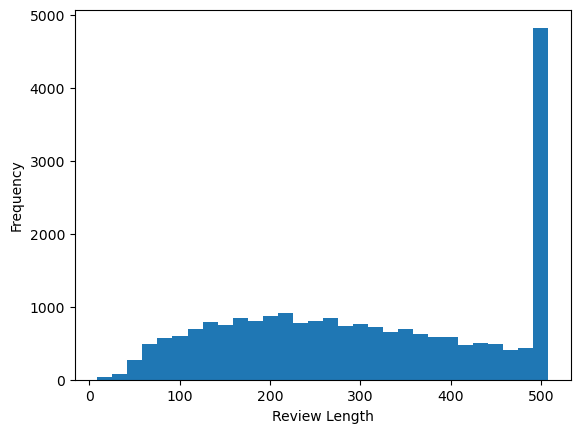

In [32]:
plt.hist(df["Review_Length"],bins=30)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='Rating'>

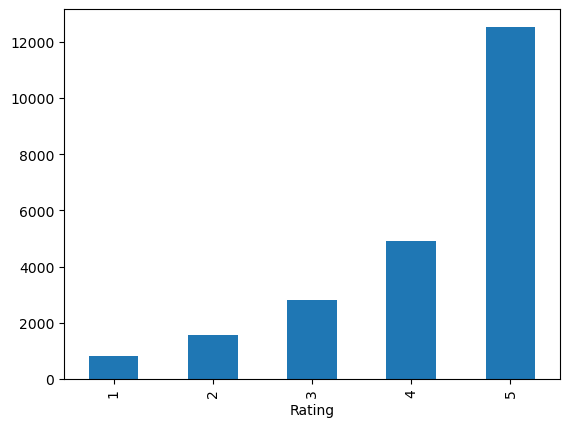

In [34]:
df["Rating"].value_counts().sort_index().plot(kind='bar')

In [11]:
df.corr(numeric_only=True)

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
Unnamed: 0,1.000000,-0.006072,-0.007749,-0.002568,-0.003887,-0.002907
Clothing ID,-0.006072,1.000000,0.017972,-0.018879,-0.016206,0.046356
Age,-0.007749,0.017972,1.000000,0.026831,0.030622,0.043079
Rating,-0.002568,-0.018879,0.026831,1.000000,0.792336,-0.064961
Recommended IND,-0.003887,-0.016206,0.030622,0.792336,1.000000,-0.069045
Positive Feedback Count,-0.002907,0.046356,0.043079,-0.064961,-0.069045,1.000000


In [15]:
df.drop(columns=['Unnamed: 0'],inplace=True)

<Axes: >

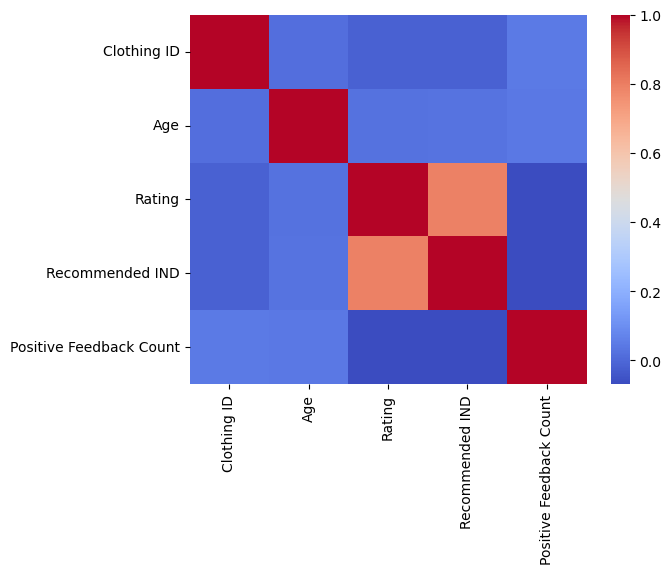

In [18]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')

In [19]:
#rating and recommendation are kinda related

In [37]:
df["Review Text"]=df["Review Text"].str.lower()


C:\Users\surya\AppData\Local\Temp\ipykernel_18340\1955081155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Review Text"]=df["Review Text"].str.lower()


In [38]:
import string
df["Review Text"]=df["Review Text"].str.translate(str.maketrans("", "", string.punctuation))

C:\Users\surya\AppData\Local\Temp\ipykernel_18340\3670724936.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Review Text"]=df["Review Text"].str.translate(str.maketrans("", "", string.punctuation))


In [39]:
import re
df["Review Text"]= df["Review Text"].apply(lambda x:re.sub(r"\d+","",x))

C:\Users\surya\AppData\Local\Temp\ipykernel_18340\3933871581.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Review Text"]= df["Review Text"].apply(lambda x:re.sub(r"\d+","",x))


In [41]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
df["tokens"]=df["Review Text"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\surya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
C:\Users\surya\AppData\Local\Temp\ipykernel_18340\2992803863.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tokens"]=df["Review Text"].apply(word_tokenize)


In [45]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=set(stopwords.words("english"))
df["tokens"]=df["tokens"].apply(lambda words: [word for word in words if word not in stop_words])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\surya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
C:\Users\surya\AppData\Local\Temp\ipykernel_18340\2727513522.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tokens"]=df["tokens"].apply(lambda words: [word for word in words if word not in stop_words])


In [46]:
df['tokens']

0        [absolutely, wonderful, silky, sexy, comfortable]
1        [love, dress, sooo, pretty, happened, find, st...
2        [high, hopes, dress, really, wanted, work, ini...
3        [love, love, love, jumpsuit, fun, flirty, fabu...
4        [shirt, flattering, due, adjustable, front, ti...
                               ...                        
23481    [happy, snag, dress, great, price, easy, slip,...
23482    [reminds, maternity, clothes, soft, stretchy, ...
23483    [fit, well, top, see, never, would, worked, im...
23484    [bought, dress, wedding, summer, cute, unfortu...
23485    [dress, lovely, platinum, feminine, fits, perf...
Name: tokens, Length: 22641, dtype: object

In [48]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lem=WordNetLemmatizer()
df['tokens']=df['tokens'].apply(lambda words:[lem.lemmatize(word) for word in words])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\surya\AppData\Roaming\nltk_data...
C:\Users\surya\AppData\Local\Temp\ipykernel_18340\4008766885.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens']=df['tokens'].apply(lambda words:[lem.lemmatize(word) for word in words])


In [49]:
df['tokens']

0        [absolutely, wonderful, silky, sexy, comfortable]
1        [love, dress, sooo, pretty, happened, find, st...
2        [high, hope, dress, really, wanted, work, init...
3        [love, love, love, jumpsuit, fun, flirty, fabu...
4        [shirt, flattering, due, adjustable, front, ti...
                               ...                        
23481    [happy, snag, dress, great, price, easy, slip,...
23482    [reminds, maternity, clothes, soft, stretchy, ...
23483    [fit, well, top, see, never, would, worked, im...
23484    [bought, dress, wedding, summer, cute, unfortu...
23485    [dress, lovely, platinum, feminine, fit, perfe...
Name: tokens, Length: 22641, dtype: object

In [50]:
df['clean_review']=df['tokens'].apply(lambda words:" ".join(words))

C:\Users\surya\AppData\Local\Temp\ipykernel_18340\2019858756.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_review']=df['tokens'].apply(lambda words:" ".join(words))


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=4999)
X=tfidf.fit_transform(df['clean_review'])

In [53]:
X.shape

(22641, 4999)

In [54]:
tfidf.get_feature_names_out()

array(['aa', 'ab', 'abby', ..., 'zipping', 'zone', 'zoom'],
      shape=(4999,), dtype=object)

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia=[]
K=range(1,11)
for i in K:
    model=KMeans(n_clusters=i,
                 random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

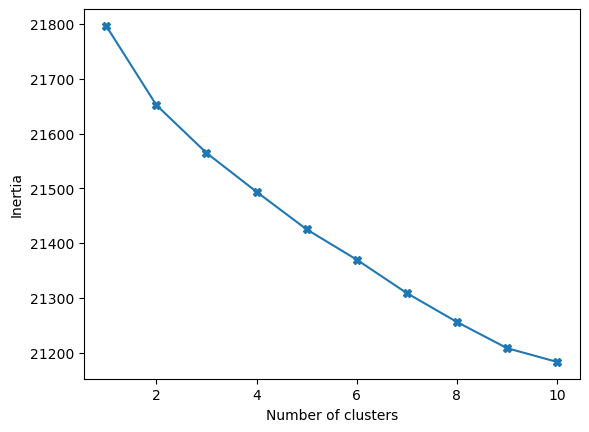

In [60]:
plt.plot(K,empty,marker='X')
plt.xlabel(
    "Number of clusters"
)
plt.ylabel(
    "Inertia"
)
plt.show()

In [62]:
from sklearn.metrics import silhouette_score
scores=[]
for i in range (2,11):
    model=KMeans(n_clusters=i,random_state=42)
    labels=model.fit_predict(X)
    score=silhouette_score(X,labels)
    scores.append(score)
print(scores)

[0.00494710617454942, 0.0052910331617314005, 0.0051793579367176955, 0.006139271199310954, 0.006222497907532044, 0.006999186599307433, 0.007883685669505432, 0.008306482066674874, 0.008181193397580614]


In [64]:
kmeans=KMeans(
    n_clusters=4,random_state=42)
clusters=kmeans.fit_predict(X)
df["Clusters"]=clusters

C:\Users\surya\AppData\Local\Temp\ipykernel_18340\511069915.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Clusters"]=clusters


Clusters
1     3427
2     4263
0     4909
3    10042
Name: count, dtype: int64


<Axes: xlabel='Clusters'>

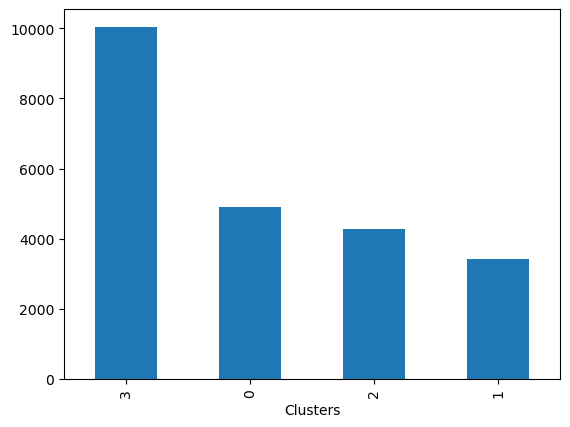

In [68]:
print(df["Clusters"].value_counts(ascending=True))
df["Clusters"].value_counts().plot(
    kind='bar'
)

In [70]:
df[df['Clusters']==0]['clean_review'].head()

1     love dress sooo pretty happened find store im ...
2     high hope dress really wanted work initially o...
7     ordered carbon store pick ton stuff always try...
8     love dress usually get x run little snug bust ...
14    nice choice holiday gathering like length graz...
Name: clean_review, dtype: object

In [71]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X.toarray())

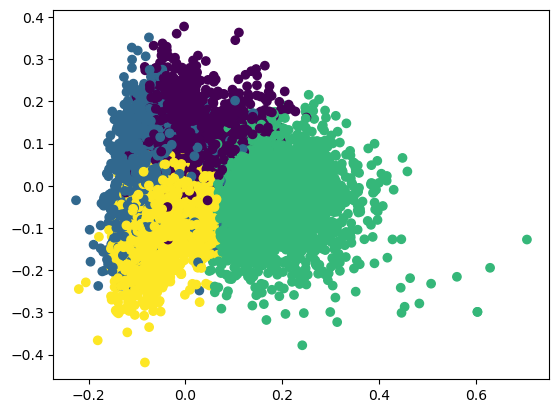

In [73]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=df["Clusters"])

In [74]:
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()
for i in range(kmeans.n_clusters):
    print(f"\nCluster {i}")
    for ind in order_centroids[i, :10]:
        print(terms[ind])


Cluster 0
size
small
fit
im
ordered
run
large
medium
wear
would

Cluster 1
top
love
look
fit
great
color
like
wear
cute
fabric

Cluster 2
dress
fit
love
wear
size
great
like
beautiful
look
flattering

Cluster 3
love
great
color
look
fit
sweater
like
shirt
wear
soft


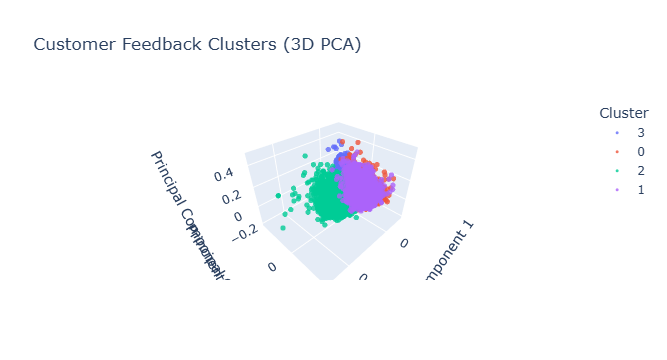

In [77]:
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X.toarray())
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "Clusters": df["Clusters"]
})
fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color=plot_df["Clusters"].astype(str),
    title="Customer Feedback Clusters (3D PCA)",
    opacity=0.8,
    labels={"color": "Clusters"}
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    ),
    legend_title="Cluster"
)